#  과제 문제

## 1. 과제 목표
- medical 데이터를 활용한 데이터 분석 리포트 작성  
- 데이터를 확인하여 통계적 특징을 도출하고, 시각화와 함께 문제 해결 방안 제시  

---

## 2. 제출 내용

### 1) 분석 코드
- Python을 활용한 데이터 분석 코드 작성  
- 변수별 통계 분석, 상관관계 분석, 시각화 포함  

### 2) 분석 리포트
- 데이터 설명 (데이터 수, 변수 설명 - 각 변수의 의미, 데이터 타입 등)  
- 분석 코드 설명  
- 분석 결과 및 결론 설명 (변수별 통계 분석 결과, 변수 간 상관관계 분석, 시각화 결과 포함)  
- 문제 해결 방법 제안 (분석 결과를 기반으로 한 노쇼 원인 파악 및 개선 방안 제시)  


In [4]:
import pandas as pd                     # pandas 라이브러리
import seaborn as sns                   # matplotlib 기반 색 테마 차트 추가하는 seaborn 라이브러리
import matplotlib.pyplot as plt         # ㅂmatplotlib 라이브러리
import numpy as np
from scipy.stats import chi2_contingency

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False



In [20]:
medical = pd.read_excel('data/medical.xls')
medical

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,SMS_received,No-show
0,29900000000000,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,No
1,559000000000000,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,No
2,4260000000000,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,No
3,868000000000,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,No
4,8840000000000,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,No
...,...,...,...,...,...,...,...,...,...
65530,749000000000000,5606399,F,2016-04-20T10:13:04Z,2016-05-19T00:00:00Z,69,SÃO CRISTÓVÃO,0,No
65531,81200000000000,5603951,F,2016-04-20T07:32:19Z,2016-05-06T00:00:00Z,35,SÃO CRISTÓVÃO,1,Yes
65532,37400000000000,5605835,M,2016-04-20T09:31:06Z,2016-05-13T00:00:00Z,65,SÃO CRISTÓVÃO,0,Yes
65533,45145119925,5606859,F,2016-04-20T10:47:37Z,2016-05-20T00:00:00Z,78,SÃO CRISTÓVÃO,0,No


# Medical 데이터 정보

In [21]:
# Medical 데이터 정보
print("Medical 데이터: ", medical.shape)                   # Medical 데이터 행과 열의 개수
medical.columns                 # Medical 데이터 열 내용
medical.info()                  # Medical 데이터 정보
medical.describe()              # Medical 데이터 통계 요약 내용

print(medical['No-show'].value_counts())

''' Medical 데이터
    Medical 데이터 / 행 개수: 65535 열 개수: 9
    PatientID : 환자 ID                 / Ex) 29900000000000
    AppointmentID : 예약 ID             /     5642903
    Gender : 성별                       /     F(여자), M(남자)
    ScheduledDay : 예약 날짜            /      2016-04-29T18:38:08Z
    AppointmentDay : 진료 날짜          /      2016-04-29T00:00:00Z   
    Age : 나이                         /       0 ~ 115
    Neighbourhood : 병원 위치           /      JARDIM DA PENHA  
    SMS_received : 문자 메시지 수신 여부 /       0(수신 안함), 1(수신 함)
    No-show : 내원 여부                /       No(내원 함), Yes(내원 안함)       
    
 '''

Medical 데이터:  (65535, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65535 entries, 0 to 65534
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   PatientId       65535 non-null  int64 
 1   AppointmentID   65535 non-null  int64 
 2   Gender          65535 non-null  object
 3   ScheduledDay    65535 non-null  object
 4   AppointmentDay  65535 non-null  object
 5   Age             65535 non-null  int64 
 6   Neighbourhood   65535 non-null  object
 7   SMS_received    65535 non-null  int64 
 8   No-show         65535 non-null  object
dtypes: int64(4), object(5)
memory usage: 4.5+ MB
No-show
No     51614
Yes    13921
Name: count, dtype: int64


' Medical 데이터\n    Medical 데이터 / 행 개수: 65535 열 개수: 9\n    PatientID : 환자 ID                 / Ex) 29900000000000\n    AppointmentID : 예약 ID             /     5642903\n    Gender : 성별                       /     F(여자), M(남자)\n    ScheduledDay : 예약 날짜            /      2016-04-29T18:38:08Z\n    AppointmentDay : 진료 날짜          /      2016-04-29T00:00:00Z   \n    Age : 나이                         /       0 ~ 115\n    Neighbourhood : 병원 위치           /      JARDIM DA PENHA  \n    SMS_received : 문자 메시지 수신 여부 /       0(수신 안함), 1(수신 함)\n    No-show : 내원 여부                /       No(내원 함), Yes(내원 안함)       \n\n '

# 데이터 전처리 (결측치 및 이상치 제거)

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
SMS_received      0
No-show           0
dtype: int64
PatientId         False
AppointmentID     False
Gender            False
ScheduledDay      False
AppointmentDay    False
Age               False
Neighbourhood     False
SMS_received      False
No-show           False
dtype: bool
0        False
1        False
2        False
3        False
4        False
         ...  
65530    False
65531    False
65532    False
65533    False
65534    False
Length: 65535, dtype: bool


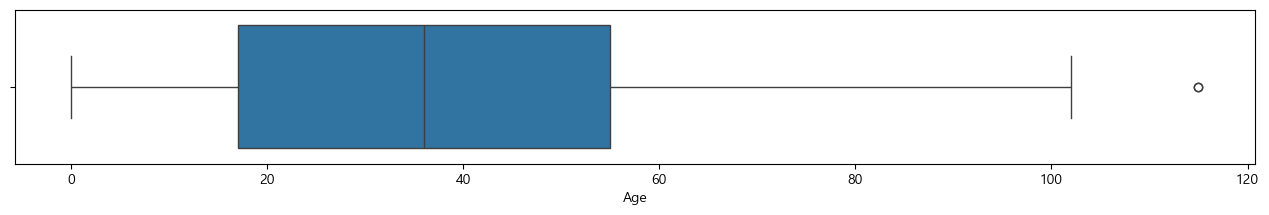

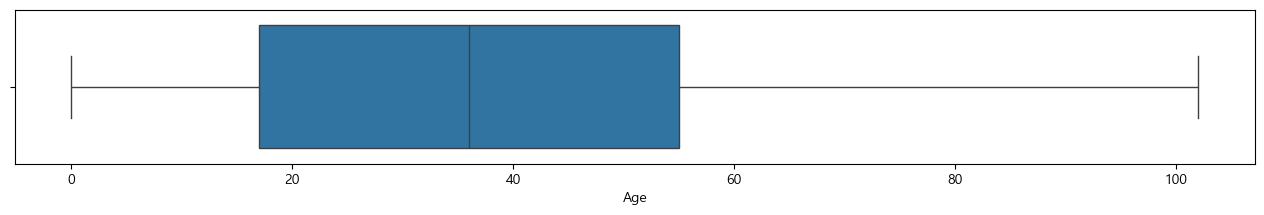

In [ ]:
# 데이터 전처리
# 결측치 확인
print(medical.isnull().sum())         # Medical 데이터 결측치 확인
print(medical.isnull().any(axis=0))   # Medical 데이터 결측치 확인
print(medical.isnull().any(axis=1))   # Medical 데이터 결측치 확인
# 결측치 없음

# 이상치 확인 및 제거
medical.Age.unique()
medical = medical[medical.Age >= 0]   # 나이 이상치 제거
plt.figure(figsize=(16, 2))

# 상자그림으로 나이 시각화 및 이상치 제거
sns.boxplot(x=medical.Age)               # 나이 이상치 시각화
# => 나이 이상치 115세 
medical = medical[medical.Age <= 110]    # 나이 이상치 제거
plt.figure(figsize=(16, 2))
sns.boxplot(x=medical.Age)               # 나이 이상치 시각화

medical = medical[medical['Gender'].isin(['F', 'M'])]        # 성별 이상치 제거
medical = medical[medical['No-show'].isin(['No', 'Yes'])]    # 내원 여부 이상치 제거


# WaitingDay 추가

In [8]:
# 데이터 처리를 위한 WaitngDay 열 추가
medical['ScheduledDay'] = pd.to_datetime(medical['ScheduledDay']).dt.date     # 예약 날짜 형식 변환
medical['AppointmentDay'] = pd.to_datetime(medical['AppointmentDay']).dt.date # 진료 날짜 형식 변환

# WaitingDay 생성
medical['WaitingDay'] = (medical['AppointmentDay'] - medical['ScheduledDay']).apply(lambda x: x.days)  # 예약 날짜와 진료 날짜의 차이 계산
print(medical[['ScheduledDay', 'AppointmentDay', 'WaitingDay']])

# WaitingDay: AppointmentDay(진료 날짜) - ScheduledDay(예약 날짜)

# 방문 당일 예약한 환자 중 노쇼 비율 확인
a = medical[medical['WaitingDay'].isin([0, -1])].shape[0]                                       # WaitingDay가 0, -1인 환자 수
b = medical[(medical['WaitingDay'].isin([0, -1])) & (medical['No-show'] == 'Yes')].shape[0]     # WaitingDay가 0, -1이고 No-show가 Yes인 환자 수
print("방문 당일 예약 환자의 노쇼 비율:", b/a)



      ScheduledDay AppointmentDay  WaitingDay
0       2016-04-29     2016-04-29           0
1       2016-04-29     2016-04-29           0
2       2016-04-29     2016-04-29           0
3       2016-04-29     2016-04-29           0
4       2016-04-29     2016-04-29           0
...            ...            ...         ...
65530   2016-04-20     2016-05-19          29
65531   2016-04-20     2016-05-06          16
65532   2016-04-20     2016-05-13          23
65533   2016-04-20     2016-05-20          30
65534   2016-04-20     2016-05-06          16

[65533 rows x 3 columns]
방문 당일 예약 환자의 노쇼 비율: 0.04960535976505139


# 재방문 환자 분석

In [23]:
# 재방문 환자의 확인

total_patient = medical.shape[0]                    # 전체 환자 수 65535      
print("재방문 환자의 확인:", total_patient, "\n")

# 고유 환자 수
unique_patient = medical['PatientId'].nunique()     # 고유 환자 수 5166
print("고유 환자 수:", unique_patient, "\n")

# medical 데이터 재방문 횟수 상위 10명
medical_top10 = medical['PatientId'].value_counts().iloc[0:10]    # 상위 10명의 환자 방문 횟수
print("Medical 데이터 재방문 횟수 상위 10명:", medical_top10)


재방문 환자의 확인: 65535 

고유 환자 수: 5166 

Medical 데이터 재방문 횟수 상위 10명: PatientId
822000000000000    91
75800000000000     85
26900000000000     79
33500000000000     79
14500000000000     78
81900000000000     78
66800000000000     75
65400000000000     71
89200000000000     70
46800000000000     66
Name: count, dtype: int64


# 데이터 분석 시각화
---

# 0. 노쇼 데이터와 관련 있는 속성의 분석 시각화

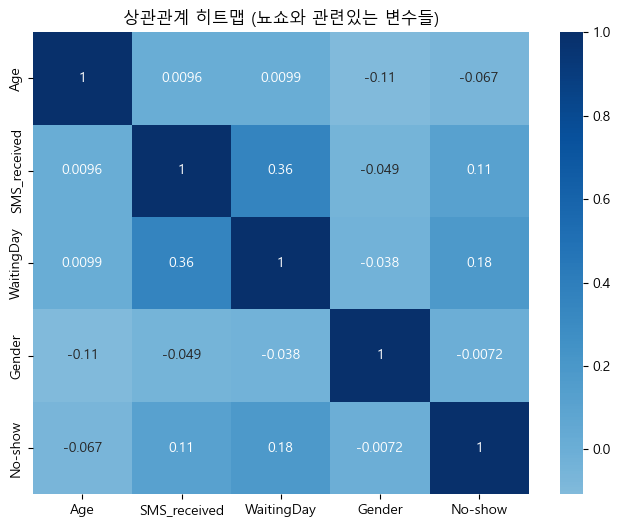

' Age & No-show = -0.067 \n    => Age와 No-show의 상관관계는 약함 Age가 높을수록 No-show가 낮아짐 상대적 나이가 높은 사람이 No-show가 적음\n\n    SMS_received & No-show = 0.11\n    => SMS와 No-show의 상관관계는 Age에 비해 강함\n\n    WaitingDay & No-show = 0.18\n    => WaitingDay는 다른 속성에 비해 강한 상관관계를 나타냄\n\n    Gender & No-show = -0.0072\n    => 굉장히 낮은 상관관계를 나타냄 즉 Gender는 No-show와 관련이 없음\n'

In [ ]:
medical['No-show'] = medical['No-show'].map({'No': 0, 'Yes': 1})                        # 데이터 heatmap 시각화를 위해 No-show 속성을 0과 1 로 변환
medical['Gender'] = medical['Gender'].map({'F': 0, 'M': 1})                             # Gender 속성을 0과 1로 변환
related_cols = ['Age', 'SMS_received', 'WaitingDay', 'Gender', 'No-show']               # 노쇼 데이터과 관련 있는 속성
corr = medical[related_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', center=0)
plt.title('상관관계 히트맵 (뇨쇼와 관련있는 변수들)')
plt.show()

# 히트맵 결과 분석
''' Age & No-show = -0.067 
    => Age와 No-show의 상관관계는 약함 

    SMS_received & No-show = 0.11
    => SMS와 No-show의 상관관계는 Age에 비해 강함

    WaitingDay & No-show = 0.18
    => WaitingDay는 다른 속성에 비해 강한 상관관계를 나타냄

    Gender & No-show = -0.0072
    => 굉장히 낮은 상관관계를 나타냄 즉 Gender는 No-show와 관련이 없음
'''

# 1. Age와 No-show 데이터 비교
- 가설: Age(나이)가 많을수록 No-show가 적을 것

  AgeGroup   No-show
0     0-20  0.235102
1    20-60  0.219240
2   60-100  0.157278
AgeGroup
0-20      0.310942
20-60     0.554063
60-100    0.134995
Name: proportion, dtype: float64


C:\Users\a6742\AppData\Local\Temp\ipykernel_25360\287012734.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_noshow1 = medical.groupby('AgeGroup')['No-show'].mean().reset_index()                   # 각 연령대 구간에서 No-show를 한 환자가 얼마나 차지하는지 비율 표시
C:\Users\a6742\AppData\Local\Temp\ipykernel_25360\287012734.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_noshow1, x='AgeGroup', y='No-show', palette="viridis")                # 각 연령대에 대한 노쇼 비교


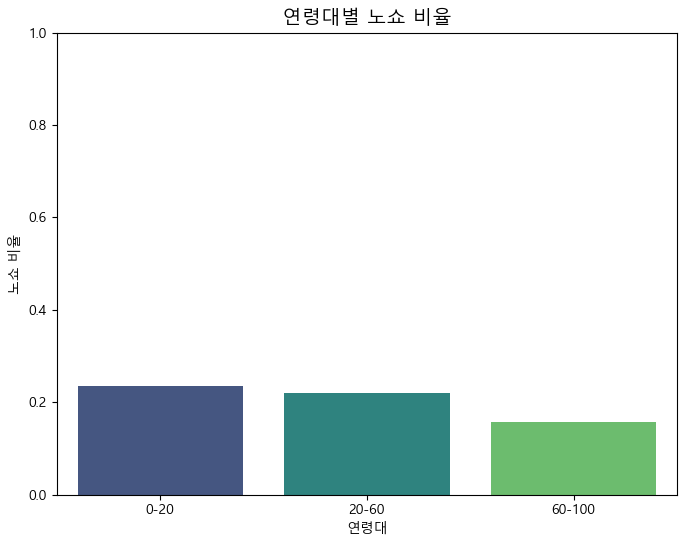

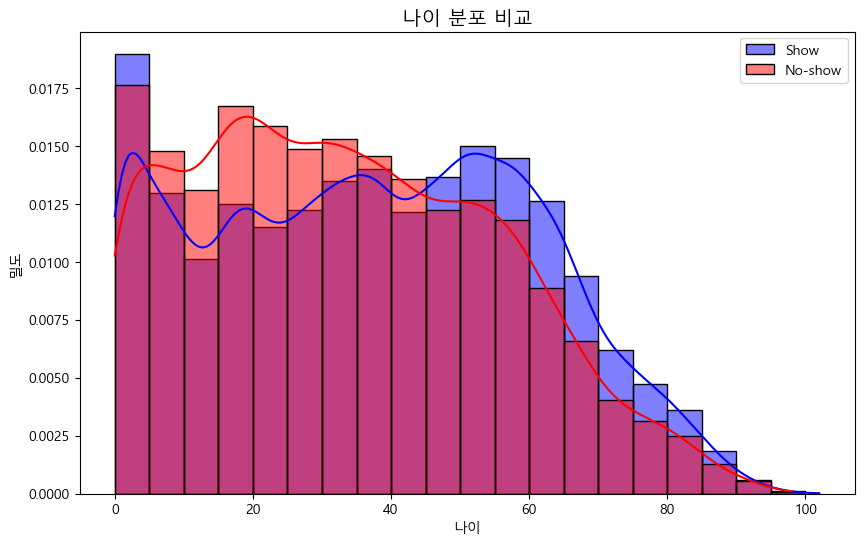

In [11]:
# Age에 따른 No-show의 비율 비교
# 연령대를 0 ~ 20 / 20 ~ 60 / 60 ~ 100

bins = [0, 20, 60, 100]
labels = ['0-20', '20-60', '60-100']                                                        # 연령대를 3개의 그룹으로 나눔
medical['AgeGroup'] = pd.cut(medical['Age'], bins=bins, labels=labels, right=False)         # 각 연령대에 알맞게 나이 그룹을 쪼갬
age_noshow1 = medical.groupby('AgeGroup')['No-show'].mean().reset_index()                   # 각 연령대 구간에서 No-show를 한 환자가 얼마나 차지하는지 비율 표시
print(age_noshow1)
''' 0 ~ 20 세 : 23%
    20 ~ 60세 : 21%
    60 ~ 100세: 15%
'''

no_show = medical[medical['No-show'] == 1]                                                  # No_show만 필터링
age_noshow2 = no_show['AgeGroup'].value_counts(normalize=True).sort_index()                 # 전체 No_show에 대한 연령대의 비율 
print(age_noshow2)
''' 0 ~ 20 세 : 31%
    20 ~ 60세 : 55%
    60 ~ 100세: 13%
    ㅡㅡㅡㅡㅡㅡㅡㅡㅡ
    총 합계: 100%
'''

plt.figure(figsize=(8,6))
sns.barplot(data=age_noshow1, x='AgeGroup', y='No-show', palette="viridis")                # 각 연령대에 대한 노쇼 비교
plt.title("연령대별 노쇼 비율", fontsize=14)
plt.xlabel("연령대")
plt.ylabel("노쇼 비율")
plt.ylim(0, 1)
plt.show()

''' 전체 연령대에 대해서 각 연령대 나이의 비율 밀도를 사용
    5 ~ 40 세: No-show가 높게 나타남 
    40 ~ 60세: show가 더 높게 나타남
    60 ~ 100세: 환자가 많이 줄어들지만 show가 더 높게 나타남
'''
plt.figure(figsize=(10, 6))
bins = range(0, 101, 5)
sns.histplot(data=medical[medical['No-show']==0]['Age'], bins=bins, color='blue', label='Show', kde=True, stat="density", alpha=0.5)
sns.histplot(data=medical[medical['No-show']==1]['Age'], bins=bins, color='red', label='No-show', kde=True, stat="density", alpha=0.5)
plt.title("나이 분포 비교", fontsize=14)
plt.xlabel("나이")
plt.ylabel("밀도")
plt.legend()
plt.show()


# 2. WaitingDay 와 No-show의 비교
- 가설: WaitingDay가 길수록 No-show가 많을 것

  WaitingGroup   No-show
0           0일  0.049475
1         1~7일  0.248760
2        8~14일  0.319049
3       15~30일  0.340905
4         31일~  0.331724


C:\Users\a6742\AppData\Local\Temp\ipykernel_25360\845385285.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wait_noshow = medical.groupby('WaitingGroup')['No-show'].mean().reset_index()
C:\Users\a6742\AppData\Local\Temp\ipykernel_25360\845385285.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=wait_noshow, x='WaitingGroup', y='No-show', palette="viridis")


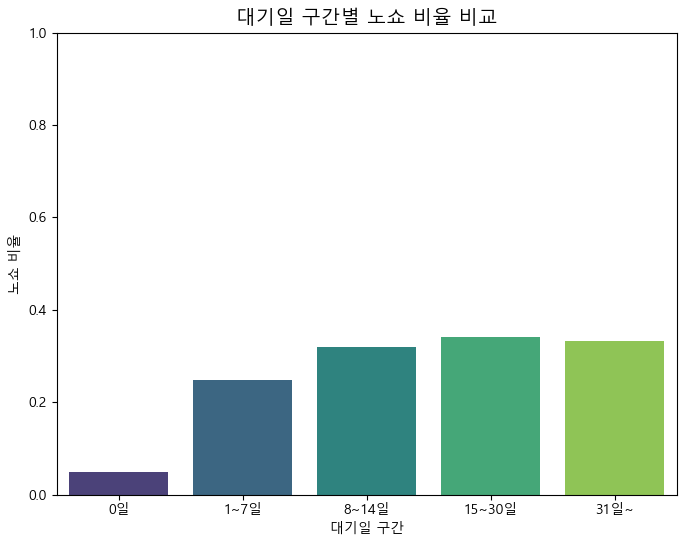

C:\Users\a6742\AppData\Local\Temp\ipykernel_25360\845385285.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["10일 이하", "50일 이상"], y=[rate1, rate2], palette="viridis")


WaitingDay 10일 이하 노쇼 비율: 0.15694373881734444
No-show
0    38166
1     7105
Name: count, dtype: int64
WaitingDay 50일 이상 노쇼 비율: 0.2987179487179487
No-show
0    1094
1     466
Name: count, dtype: int64


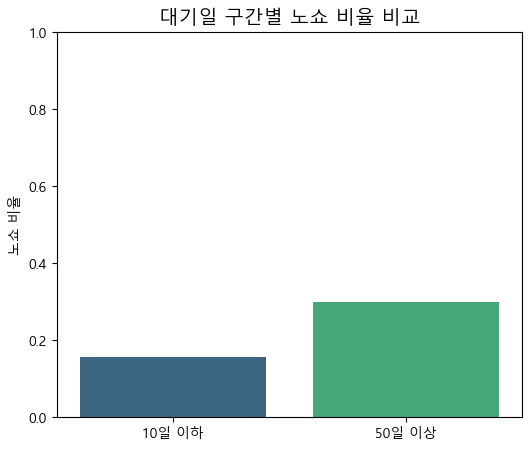

In [12]:

# WaitingDay 구간화
bins = [-1, 0, 7, 14, 30, 176]                                                              # 176일이 최대 waitingDay
labels = ['0일', '1~7일', '8~14일', '15~30일', '31일~']
medical['WaitingGroup'] = pd.cut(medical['WaitingDay'], bins=bins, labels=labels)

# 그룹별 노쇼율 계산
wait_noshow = medical.groupby('WaitingGroup')['No-show'].mean().reset_index()
print(wait_noshow)

plt.figure(figsize=(8,6))
sns.barplot(data=wait_noshow, x='WaitingGroup', y='No-show', palette="viridis")
plt.title("대기일 구간별 노쇼 비율 비교", fontsize=14)
plt.xlabel("대기일 구간")
plt.ylabel("노쇼 비율")
plt.ylim(0, 1)
plt.show()

# 15 ~ 30 일, 30일 ~ 이 No-show 비율이 큼  
# 그룹별 대기일 기간이 길수록 No-show 비율이 커짐

wait_noshow1 = medical[medical['WaitingDay'] <= 10]
rate1 = wait_noshow1['No-show'].mean()
print("WaitingDay 10일 이하 노쇼 비율:", rate1)
print(wait_noshow1['No-show'].value_counts())

wait_noshow2 = medical[medical['WaitingDay'] >= 50]
rate2 = wait_noshow2['No-show'].mean()
print("WaitingDay 50일 이상 노쇼 비율:", rate2)
print(wait_noshow2['No-show'].value_counts())

plt.figure(figsize=(6,5))
sns.barplot(x=["10일 이하", "50일 이상"], y=[rate1, rate2], palette="viridis")
plt.title("대기일 구간별 노쇼 비율 비교", fontsize=14)
plt.ylabel("노쇼 비율")
plt.ylim(0, 1)
plt.show()

# 3. 재방문 환자와 No-show 데이터의 비교
- No-show가 제일 빈번한 지역 확인
- 가정: 재방문 횟수가 많은 환자일 경우 No-show가 적을 것

재방문 환자 수: 3776
모든 재방문 환자: PatientId
822000000000000    91
75800000000000     85
26900000000000     79
33500000000000     79
14500000000000     78
                   ..
29374857623         2
9578266292          2
8849459824          2
48829762551         2
63214315353         2
Name: count, Length: 3776, dtype: int64
처음 방문 환자: Index([45145119925, 99948393975, 66117912619, 37212886581, 66542988419,
       32676433343, 51619196697, 63263476293, 47228863177, 39634462959,
       ...
       54176714576, 21192916457, 87715469383, 88278187611, 89959616185,
       61462392715, 48699989773, 26942862445, 18363989692, 58437665792],
      dtype='int64', name='PatientId', length=1390)
재방문 노쇼비율:  0.2126030899708464
처음방문 노쇼비율:  0.20287769784172663


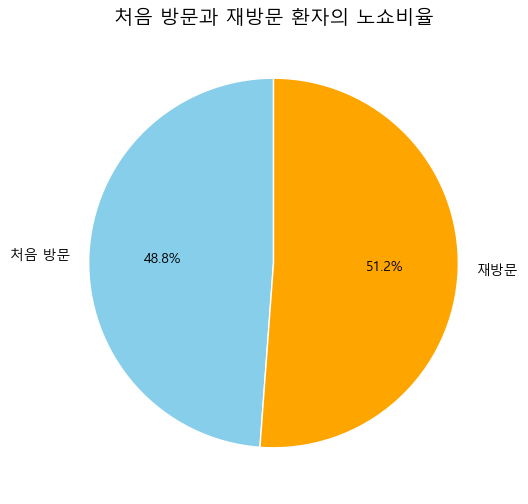

총 지역 개수: 80
지역 이름 10개: ['JARDIM DA PENHA' 'MATA DA PRAIA' 'PONTAL DE CAMBURI' 'REPÚBLICA'
 'GOIABEIRAS' 'ANDORINHAS' 'CONQUISTA' 'NOVA PALESTINA' 'DA PENHA'
 'TABUAZEIRO']


노쇼 비율이 높은 지역 Neighbourhood
ILHAS OCEÂNICAS DE TRINDADE    1.000000
SANTOS DUMONT                  0.294941
HORTO                          0.283582
ANDORINHAS                     0.280628
SANTA CECÍLIA                  0.279141
UNIVERSITÁRIO                  0.277108
SÃO PEDRO                      0.257525
AEROPORTO                      0.250000
JESUS DE NAZARETH              0.248155
ILHA DAS CAIEIRAS              0.247340
Name: No-show, dtype: float64

방문횟수 대비 노쇼 비율 높은 지역                        mean  count
Neighbourhood                     
SANTOS DUMONT      0.294941    929
HORTO              0.283582    134
ANDORINHAS         0.280628    955
SANTA CECÍLIA      0.279141    326
UNIVERSITÁRIO      0.277108     83
SÃO PEDRO          0.257525    897
JESUS DE NAZARETH  0.248155   2168
ILHA DAS CAIEIRAS  0.247340    37

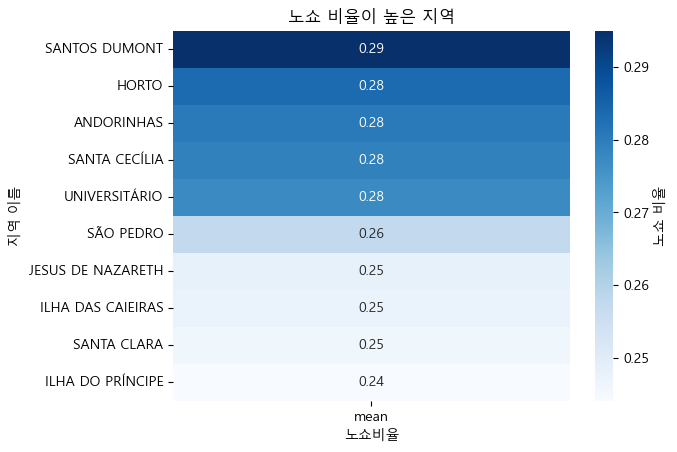

In [ ]:
patient_visit = medical['PatientId'].value_counts()                                    # 각 환자의 방문 횟수
patient_revisit = patient_visit[patient_visit > 1]                                     # 재방문 환자 Series

print("재방문 환자 수:", patient_revisit.shape[0])
print("모든 재방문 환자:", patient_revisit)

patientId_revisit = patient_visit[patient_visit > 1].index                             # 재방문 환자 ID    
revisit_data = medical[medical['PatientId'].isin(patientId_revisit)]                   # 재방문 환자의 모든 데이터 DataFrame 

first_visit_patient = patient_visit[patient_visit == 1].index                          # 처음 방문한 환자 ID
first_visit_data = medical[medical['PatientId'].isin(first_visit_patient)]
print("처음 방문 환자:", first_visit_patient)

# 노쇼율 계산
revisit_noshow_rate = revisit_data['No-show'].mean()                                    # 재방문 환자의 노쇼 비율
first_visit_noshow_rate = first_visit_data['No-show'].mean()                            # 처음 방문 환자의 노쇼 비율
print("재방문 노쇼비율: ", revisit_noshow_rate)
print("처음방문 노쇼비율: ", first_visit_noshow_rate)

labels = ["처음 방문", "재방문"]
sizes = [first_visit_noshow_rate, revisit_noshow_rate]
colors = ["skyblue", "orange"]
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct="%.1f%%", startangle=90, colors=colors, wedgeprops={'edgecolor':'white'})
plt.title("처음 방문과 재방문 환자의 노쇼비율", fontsize=14)
plt.show()


# 지역에 따른 노쇼 비교
print("총 지역 개수:", medical['Neighbourhood'].nunique())                           # 병원이 위치하는 총 지역의 개수
print("지역 이름 10개:", medical['Neighbourhood'].unique()[0:10])                    # 병원 위치 지역 이름 출력
print("\n")
region_noshow = medical.groupby('Neighbourhood')['No-show'].mean().sort_values(ascending=False)

print("노쇼 비율이 높은 지역", region_noshow.head(10))                                 # 노쇼 비율이 높은 지역 10개


region_rate = medical.groupby('Neighbourhood')['No-show'].agg(['mean', 'count'])
region_noshow = region_rate[region_rate['count'] >= 30].sort_values('mean', ascending=False)
print("\n방문횟수 대비 노쇼 비율 높은 지역", region_noshow.head(10))                                                        

ct = pd.crosstab(medical['Neighbourhood'], medical['No-show'])                      # 지역, 노쇼의 비교 카이제곱 사용 
chi2, p, dof, expected = chi2_contingency(ct)                                       # 지역 이름과 노쇼 범주형 데이터이기 때문에 카이제곱 사용
print("카이제곱 통계량:", chi2)                                                       # 카이제곱
print("p-value:", p)                                                                # 유의확률 p-value가 0.05보다 작음 귀무가설 기각 지역에 따른 노쇼 비율 차이가 있음
                                                                                    # 귀무가설: 지역에 따라 노쇼확률이 차이가 없다 

sns.heatmap(region_noshow[['mean']].head(10), annot=True, cmap='Blues', cbar_kws={'label': '노쇼 비율'})
plt.title('노쇼 비율이 높은 지역')
plt.xlabel('노쇼비율')
plt.ylabel('지역 이름')
plt.show()

# 4. SMS_Received와 No-show 데이터의 비교
- 가정: SMS문자를 받지 않은 사람이 No-show를 자주할 것

노쇼 비율 SMS_received
0    0.182816
1    0.282213
Name: No-show, dtype: float64


C:\Users\a6742\AppData\Local\Temp\ipykernel_25360\1011026187.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sms_rate.index, y=sms_rate.values, palette="coolwarm")


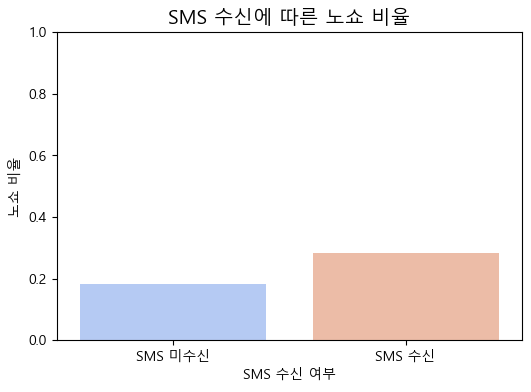

In [14]:
sms_rate = medical.groupby('SMS_received')['No-show'].mean()
print("노쇼 비율", sms_rate)

plt.figure(figsize=(6,4))
sns.barplot(x=sms_rate.index, y=sms_rate.values, palette="coolwarm")
plt.xticks([0,1], ["SMS 미수신", "SMS 수신"])
plt.title("SMS 수신에 따른 노쇼 비율", fontsize=14)
plt.ylabel("노쇼 비율")
plt.xlabel("SMS 수신 여부")
plt.ylim(0,1)
plt.show()
# SMS를 수신한 환자가 오히려 노쇼의 비율이 더 높음


---

# No-show의 원인 파악 및 개선 방안 제시
원인
- 연령대가 낮은 환자들이 No-show가 많음
- WaitingDay가 늘어날수록 No-show가 늘어남
- 지역에 따라서 No-show의 차이가 존재함

개선방안
- 연령대가 낮은(0 ~ 20세) 환자가 예약할 경우 보호자 본인이나 정보가 같이 예약되도록 시스템을 조정함
- WaitingDay를 최대한 줄이는 즉 예약날짜와 진료날짜의 차이를 최대한 줄이도록(약 2, 3일 이내) 시스템을 조정함
- No-show가 자주 발생하는 SANTOS DUMONT, HORTO 지역에는 SMS 알림이 아닌 예약금 시스템과 같은 다른 방법 또한 도입함